In [ ]:
megadescriptor_version = 'T-224'  # 'S-224', 'B-224', 'L-384'
detection = '' # '', _detected', '_detected_manual'

In [58]:
import torch
import numpy as np
import joblib
import torch.nn as nn
import torch.optim as optim
import random
from collections import defaultdict

In [59]:

# Path to new file
data_path = f"saved_models/{megadescriptor_version}/data{detection}.npz"
encoder_path = f"saved_models/{megadescriptor_version}/label_encoder{detection}.pkl"

# Load everything at once
data = np.load(data_path)

embeddings = data["embeddings"]      # shape (N, D)
labels = data["label_ids"]           # integer labels
# original_labels = data["labels"]     # string labels (optional)

print("Embeddings shape:", embeddings.shape)

# Optional: load encoder if you want inverse_transform
encoder = joblib.load(encoder_path)
names = encoder.inverse_transform(labels)

encoder = joblib.load(encoder_path)
id_to_name = dict(enumerate(encoder.classes_))
name_to_id = {v: k for k, v in id_to_name.items()}


Embeddings shape: (315, 1536)


In [60]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42
)

In [42]:
class Classifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=10, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [43]:
from proportional_split_xy import proportional_split_xy

# Triplet Loss


In [44]:
margin = 0.85

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Hard split

In [46]:
import torch
import numpy as np

def generate_hard_triplets(embeddings, labels, num_triplets_per_anchor=20, margin=1.0, device=None):
    """
    Hard triplet mining: for each anchor, pick hardest positive and hardest negative.

    Args:
        embeddings (torch.Tensor): shape (N, D)
        labels (torch.Tensor | np.ndarray): shape (N,)
        num_triplets_per_anchor (int): how many copies to make per anchor
        margin (float): triplet loss margin
        device (torch.device): e.g., torch.device('cuda') or ('cpu')
    """
    if device is None:
        device = torch.device("cpu")

    # ensure tensor
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels)

    embeddings = embeddings.to(device)
    labels = labels.to(device)
    triplets = []

    # normalize embeddings for cosine-style distance
    embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)

    # pairwise Euclidean distances
    with torch.no_grad():
        dists = torch.cdist(embeddings, embeddings, p=2)

    labels_np = labels.cpu().numpy()
    n = len(labels_np)

    for anchor_idx in range(n):
        anchor_label = labels_np[anchor_idx]

        pos_indices = np.where(labels_np == anchor_label)[0]
        neg_indices = np.where(labels_np != anchor_label)[0]

        if len(pos_indices) < 2:
            continue  # skip if only one image of this class

        # hardest positive = most distant same-class example
        pos_dists = dists[anchor_idx, pos_indices]
        hardest_pos_idx = pos_indices[torch.argmax(pos_dists)].item()

        # hardest negative = closest different-class example
        neg_dists = dists[anchor_idx, neg_indices]
        hardest_neg_idx = neg_indices[torch.argmin(neg_dists)].item()

        # replicate triplet if needed
        for _ in range(num_triplets_per_anchor):
            triplets.append((anchor_idx, hardest_pos_idx, hardest_neg_idx))

    print(f"✅ Generated {len(triplets)} hard triplets on device {device}.")
    return triplets


### Semi hard split

In [47]:
def generate_semi_hard_triplets(embeddings, labels, num_triplets_per_anchor=20, margin=1.0, device=None):
    """
    Semi-hard triplet mining:
    For each anchor, choose positive that is closer than negative but still violates the margin slightly:
        d(a, p) < d(a, n) < d(a, p) + margin

    embeddings: torch.Tensor (N, D)
    labels: torch.Tensor (N,)
    """
    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels)
    if device is not None:
        embeddings = embeddings.to(device)
        labels = labels.to(device)

    triplets = []
    num_samples = len(labels)

    # Precompute pairwise distances
    dists = torch.cdist(embeddings, embeddings, p=2).detach().cpu()

    labels_np = labels.cpu().numpy()

    for anchor_idx in range(num_samples):
        anchor_label = labels_np[anchor_idx]

        pos_indices = np.where(labels_np == anchor_label)[0]
        neg_indices = np.where(labels_np != anchor_label)[0]
        if len(pos_indices) < 2 or len(neg_indices) == 0:
            continue

        # Hardest positive (furthest same-class)
        d_ap_all = dists[anchor_idx, pos_indices]
        d_ap_all = d_ap_all[d_ap_all > 0]  # exclude self
        if len(d_ap_all) == 0:
            continue

        for _ in range(num_triplets_per_anchor):
            pos_idx = np.random.choice(pos_indices)
            d_ap = dists[anchor_idx, pos_idx]

            # Find semi-hard negatives
            d_an_candidates = dists[anchor_idx, neg_indices]
            mask = (d_an_candidates > d_ap) & (d_an_candidates < d_ap + margin)
            valid_negatives = neg_indices[mask.numpy()]

            if len(valid_negatives) == 0:
                # fallback to hardest negative
                neg_idx = neg_indices[d_an_candidates.argmin().item()]
            else:
                neg_idx = np.random.choice(valid_negatives)

            triplets.append((anchor_idx, pos_idx, neg_idx))

    print(f"Generated {len(triplets)} semi-hard triplets.")
    return triplets


### With indices


In [48]:
def generate_semi_hard_triplets(
    embeddings,
    labels,
    indices=None,                 # NEW
    num_triplets_per_anchor=20,
    margin=1.0,
    device=None
):
    """
    Semi-hard triplet mining on a subset of indices.

    embeddings: (N, D)
    labels: (N,)
    indices: list/array of sample indices to use as anchors
    """

    if isinstance(labels, np.ndarray):
        labels = torch.from_numpy(labels)

    if device is not None:
        embeddings = embeddings.to(device)
        labels = labels.to(device)

    if indices is None:
        indices = np.arange(len(labels))
    else:
        indices = np.array(indices)

    triplets = []

    # Compute global pairwise distances once
    dists = torch.cdist(embeddings, embeddings, p=2).detach().cpu()
    labels_np = labels.cpu().numpy()

    for anchor_idx in indices:
        anchor_label = labels_np[anchor_idx]

        pos_indices = np.where(labels_np == anchor_label)[0]
        neg_indices = np.where(labels_np != anchor_label)[0]

        # remove self from positives
        pos_indices = pos_indices[pos_indices != anchor_idx]

        if len(pos_indices) == 0 or len(neg_indices) == 0:
            continue

        for _ in range(num_triplets_per_anchor):

            pos_idx = np.random.choice(pos_indices)
            d_ap = dists[anchor_idx, pos_idx]

            d_an_candidates = dists[anchor_idx, neg_indices]
            mask = (d_an_candidates > d_ap) & (d_an_candidates < d_ap + margin)
            valid_negatives = neg_indices[mask.numpy()]

            if len(valid_negatives) == 0:
                # fallback: hardest negative
                neg_idx = neg_indices[d_an_candidates.argmin().item()]
            else:
                neg_idx = np.random.choice(valid_negatives)

            triplets.append((anchor_idx, pos_idx, neg_idx))

    print(f"Generated {len(triplets)} semi-hard triplets.")
    return triplets


### Random split

In [49]:
# ------------------------------
# Model: scales each embedding dimension independently
# ------------------------------
class ScaledEmbeddingModel(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(emb_dim))
    def forward(self, x):
        return x * self.scale


# ------------------------------
# Compute accuracy: fraction of triplets where anchor-positive < anchor-negative
# ------------------------------
def compute_triplet_accuracy(model, embeddings, triplets):
    correct = 0
    with torch.no_grad():
        for (a, p, n) in triplets:
            anchor = model(embeddings[a].unsqueeze(0))
            positive = model(embeddings[p].unsqueeze(0))
            negative = model(embeddings[n].unsqueeze(0))
            dist_pos = torch.norm(anchor - positive, p=2)
            dist_neg = torch.norm(anchor - negative, p=2)
            if dist_pos < dist_neg:
                correct += 1
    return correct / len(triplets)


# ------------------------------
# Stratified random split of triplets
# - ensures disjoint train/test triplets
# - ensures each class (anchor label) appears in both sets
# ------------------------------
import numpy as np
import torch
import random
from collections import defaultdict


### Stratified index split

In [50]:
def stratified_index_split(labels, test_ratio=0.2, seed=42):
    """
    Stratified split of sample indices.

    Ensures:
    - Disjoint train/val indices
    - Every class appears in both sets (if class size > 1)

    labels: array-like of shape (N,)
    """

    random.seed(seed)
    np.random.seed(seed)

    labels = np.array(labels)
    unique_classes = np.unique(labels)

    train_indices = []
    val_indices = []

    for cls in unique_classes:
        cls_indices = np.where(labels == cls)[0]
        np.random.shuffle(cls_indices)

        n_total = len(cls_indices)
        n_val = max(1, int(n_total * test_ratio))

        if n_total == 1:
            # cannot split
            train_indices.extend(cls_indices)
        else:
            val_indices.extend(cls_indices[:n_val])
            train_indices.extend(cls_indices[n_val:])

    train_indices = np.array(train_indices)
    val_indices = np.array(val_indices)

    print("========== STRATIFIED INDEX SPLIT ==========")
    print("Train size:", len(train_indices))
    print("Val size:", len(val_indices))
    print("Overlap:", len(set(train_indices) & set(val_indices)))

    return train_indices, val_indices


In [51]:
# ------------------------------
# Training loop
# ------------------------------
def train_triplet_loss(embeddings, train_triplets, val_triplets,
                       emb_dim=128, lr=1e-3, margin=1.0, epochs=50):
    model = ScaledEmbeddingModel(emb_dim)
    criterion = nn.TripletMarginLoss(margin=margin)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        if epoch != 0:
            model.train()
        total_loss = 0.0

        for (a, p, n) in train_triplets:
            anchor = model(embeddings[a].unsqueeze(0))
            positive = model(embeddings[p].unsqueeze(0))
            negative = model(embeddings[n].unsqueeze(0))

            loss = criterion(anchor, positive, negative)
            if epoch != 0:                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()

        model.eval()
        train_acc = compute_triplet_accuracy(model, embeddings, train_triplets)
        val_acc = compute_triplet_accuracy(model, embeddings, val_triplets)

        print(f"Epoch {epoch:02d} | loss: {total_loss/len(train_triplets):.6f} | "
              f"train_acc: {train_acc:.3f} | val_acc: {val_acc:.3f}")

    print("\n✅ Final Validation Accuracy:", 
          round(compute_triplet_accuracy(model, embeddings, val_triplets), 4))
    return model

In [52]:
def generate_triplets(indices, labels, num_triplets_per_anchor=20):
    triplets = []
    # Handle both torch.Tensor and np.ndarray
    labels_np = labels.cpu().numpy() if isinstance(labels, torch.Tensor) else np.array(labels)

    for anchor_idx in indices:
        anchor_label = labels_np[anchor_idx]

        # Positive samples (same class, excluding anchor)
        pos_indices = [i for i in indices if labels_np[i] == anchor_label and i != anchor_idx]
        # Negative samples (different class)
        neg_indices = [i for i in indices if labels_np[i] != anchor_label]

        if len(pos_indices) == 0 or len(neg_indices) == 0:
            continue

        for _ in range(num_triplets_per_anchor):
            p = random.choice(pos_indices)
            n = random.choice(neg_indices)
            triplets.append((anchor_idx, p, n))

    return triplets

C:\Users\user\AppData\Local\Temp\ipykernel_15156\1123045260.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_classes)


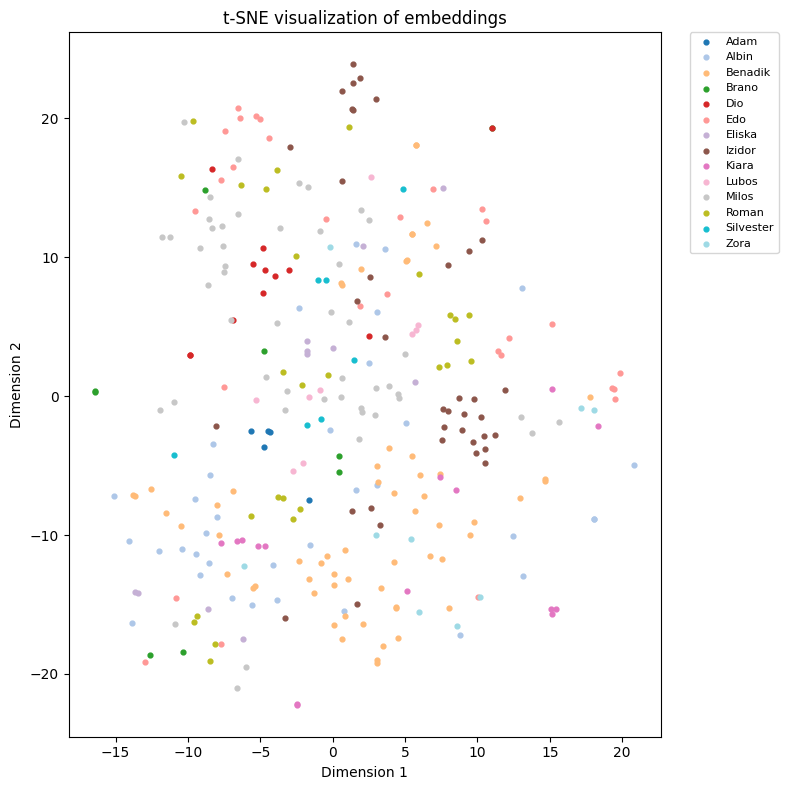

In [61]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

unique_labels = np.unique(labels)
num_classes = len(unique_labels)

# Use high-contrast categorical colormap
cmap = cm.get_cmap('tab20', num_classes)

plt.figure(figsize=(8, 8))

for label in unique_labels:
    mask = labels == label
    
    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=12,
        color=cmap(label),              # use label as color index
        label=id_to_name[label]         # use class name in legend
    )

plt.title("t-SNE visualization of embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [62]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("KNN accuracy:", acc)

KNN accuracy: 0.49206349206349204


In [56]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedShuffleSplit

def evaluate_accuracy_np(embeddings, labels, query_ratio=0.2, seed=42):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=query_ratio, random_state=seed)
    db_idx, q_idx = next(sss.split(embeddings, labels))
    N = len(labels)
    idx = np.arange(N)
    np.random.shuffle(idx)

    split = int(N * (1 - query_ratio))
    db_idx = idx[:split]
    q_idx = idx[split:]

    db_emb = embeddings[db_idx]
    db_labels = labels[db_idx]

    q_emb = embeddings[q_idx]
    q_labels = labels[q_idx]

    # L2 normalize (important for cosine!)
    db_emb = db_emb / np.linalg.norm(db_emb, axis=1, keepdims=True)
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)

    sim = cosine_similarity(q_emb, db_emb)

    nearest = np.argmax(sim, axis=1)
    predictions = db_labels[nearest]

    accuracy = np.mean(predictions == q_labels)
    print(f"Query ratio: {query_ratio} Accuracy: {accuracy:.4f}")

    return accuracy



In [63]:

evaluate_accuracy_np(embeddings, labels, query_ratio=0.2)

Query ratio: 0.2 Accuracy: 0.5873


0.5873015873015873

### Main

In [ ]:
if __name__ == "__main__":
    import random
    import numpy as np

    torch.manual_seed(0)
    random.seed(0)

    # --- Load your embeddings and labels ---
    N, D = embeddings.shape

    # --- Split into train/val indices ---
    indices = np.arange(N)
    np.random.shuffle(indices)
    split = int(0.8 * N)
    train_idx = indices[:split]
    val_idx = indices[split:]




    # --- Generate triplets for train and val ---
    # train_triplets = generate_triplets(train_idx, labels, num_triplets_per_anchor=50)
    # val_triplets = generate_triplets(val_idx, labels, num_triplets_per_anchor=50)

    # all_triplets = generate_semi_hard_triplets(embeddings, labels, num_triplets_per_anchor=20)
    train_indices, val_indices = stratified_index_split(labels, test_ratio=0.2)

    # train_triplets = generate_semi_hard_triplets(embeddings, labels, indices=train_indices)
    # val_triplets = generate_semi_hard_triplets(embeddings, labels, indices=val_indices)


    # train_triplets = generate_hard_triplets(embeddings[train_idx], labels[train_idx], num_triplets_per_anchor=150, margin=1.1, device=device)
    # val_triplets   = generate_hard_triplets(embeddings[val_idx], labels[val_idx], num_triplets_per_anchor=50, margin=1.0, device=device)

    train_triplets = generate_semi_hard_triplets(embeddings[train_idx], labels[train_idx], num_triplets_per_anchor=20, margin=1.1, device=device)
    val_triplets   = generate_semi_hard_triplets(embeddings[val_idx], labels[val_idx], num_triplets_per_anchor=20, margin=1.0, device=device)

    print(f"Generated {len(train_triplets)} training triplets and {len(val_triplets)} validation triplets.")


========== STRATIFIED INDEX SPLIT ==========
Train size: 262
Val size: 57
Overlap: 0
Generated 5100 semi-hard triplets.
Generated 1280 semi-hard triplets.
Generated 5100 training triplets and 1280 validation triplets.


In [51]:

# --- Train model ---
model = train_triplet_loss(
    embeddings, train_triplets, val_triplets,
    emb_dim=D, lr=1e-3, epochs=10
)

# --- Evaluate final accuracy ---
final_val_acc = compute_triplet_accuracy(model, embeddings, val_triplets)
print(f"\n✅ Final Validation Accuracy: {final_val_acc:.3f}")

# --- Optionally save calibrated embeddings ---
calibrated_embeddings = model(embeddings)
torch.save(calibrated_embeddings, "emb_calibrated.pt")


Epoch 00 | loss: 2.344600 | train_acc: 0.505 | val_acc: 0.489
Epoch 01 | loss: 1.979598 | train_acc: 0.513 | val_acc: 0.492
Epoch 02 | loss: 1.359889 | train_acc: 0.525 | val_acc: 0.505
Epoch 03 | loss: 1.076122 | train_acc: 0.534 | val_acc: 0.509
Epoch 04 | loss: 0.998464 | train_acc: 0.542 | val_acc: 0.509
Epoch 05 | loss: 0.974682 | train_acc: 0.545 | val_acc: 0.499
Epoch 06 | loss: 0.965681 | train_acc: 0.551 | val_acc: 0.505
Epoch 07 | loss: 0.961927 | train_acc: 0.547 | val_acc: 0.513
Epoch 08 | loss: 0.959191 | train_acc: 0.549 | val_acc: 0.517
Epoch 09 | loss: 0.957607 | train_acc: 0.551 | val_acc: 0.514

✅ Final Validation Accuracy: 0.5141

✅ Final Validation Accuracy: 0.514


In [ ]:
def verify_triplet_split(train_triplets, val_triplets):
    print("\n========== VERIFYING TRIPLET SPLIT ==========")

    # ---- 1. Index overlap ----
    train_indices = set(i for t in train_triplets for i in t)
    val_indices   = set(i for t in val_triplets for i in t)

    overlap_indices = train_indices & val_indices

    print(f"Train unique indices: {len(train_indices)}")
    print(f"Val unique indices:   {len(val_indices)}")
    print(f"Overlap indices:      {len(overlap_indices)}")

    if overlap_indices:
        print("❌ WARNING: Overlapping indices detected!")
        print("Example overlapping indices:", list(overlap_indices)[:10])
    else:
        print("✅ No index overlap")

    # ---- 2. Triplet overlap ----
    train_set = set(train_triplets)
    val_set   = set(val_triplets)

    overlapping_triplets = train_set & val_set

    print(f"\nOverlapping triplets: {len(overlapping_triplets)}")

    if overlapping_triplets:
        print("❌ Exact duplicate triplets found!")
        print("Example overlapping triplets:", list(overlapping_triplets)[:5])
    else:
        print("✅ No exact triplet overlap")

    print("============================================\n")
